In [1]:
import pickle
import json
import os
import matplotlib.pyplot as plt
import numpy as np

FRAME 1
position: [-7.725807517999783e-05, -5.204819899518043e-05, -3.995932102203369] meters
velocity: [0.00037366984179243445, 0.0009245172841474414, 0.07878902554512024] meters/sec


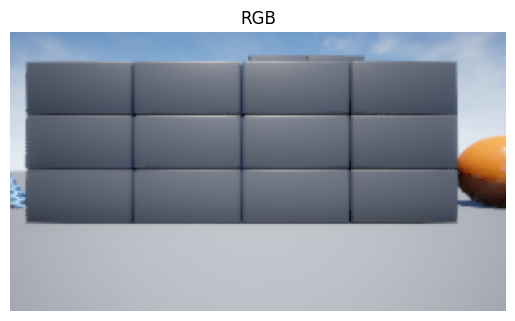

FRAME 2
position: [0.5186272859573364, 0.5169283747673035, -4.115743160247803] meters
velocity: [0.9745213985443115, 0.9707374572753906, -0.03063276968896389] meters/sec


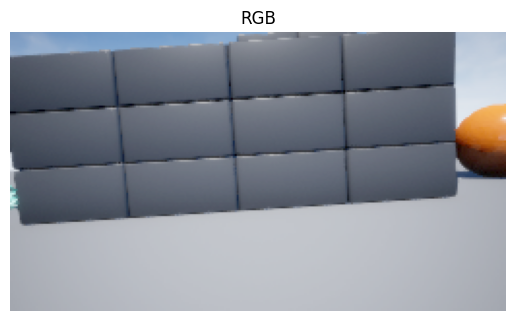

FRAME 3
position: [1.6957000494003296, 1.692781686782837, -4.114497661590576] meters
velocity: [1.2988358736038208, 1.3001457452774048, 0.010489536449313164] meters/sec


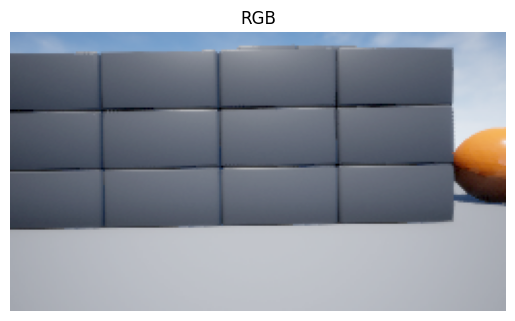

FRAME 4
position: [3.039548397064209, 3.038766384124756, -4.105889797210693] meters
velocity: [1.374098539352417, 1.3761837482452393, 0.006564626004546881] meters/sec


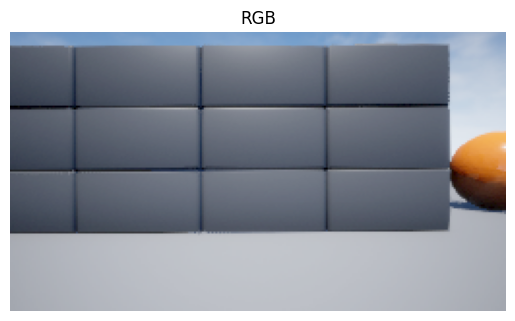

FRAME 5
position: [4.248676776885986, 4.248804569244385, -5.262197017669678] meters
velocity: [0.7463294267654419, 0.7478382587432861, -2.4026498794555664] meters/sec


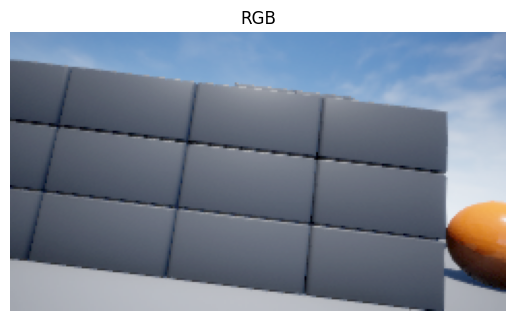

FRAME 6
position: [4.477291584014893, 4.480910301208496, -7.222503185272217] meters
velocity: [-0.24836282432079315, -0.2444668710231781, -1.1326279640197754] meters/sec


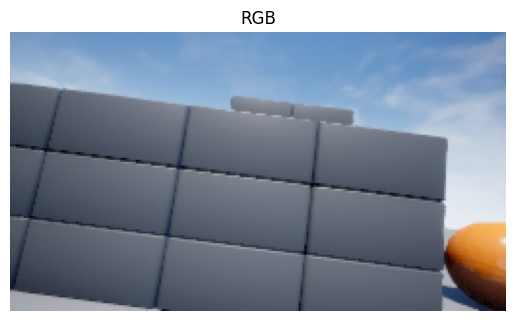

FRAME 7
position: [3.808424234390259, 3.814565896987915, -7.438558578491211] meters
velocity: [-1.0136998891830444, -1.016235113143921, -0.009245162829756737] meters/sec


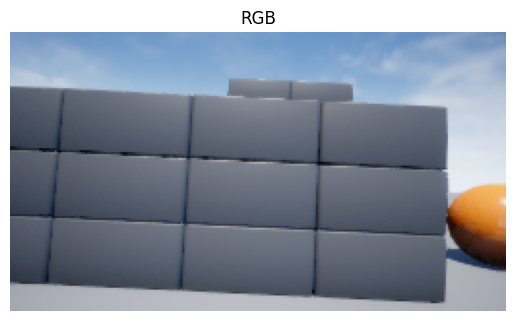

FRAME 8
position: [2.6254730224609375, 2.626887321472168, -7.431504249572754] meters
velocity: [-1.2773008346557617, -1.2821335792541504, 0.1905059963464737] meters/sec


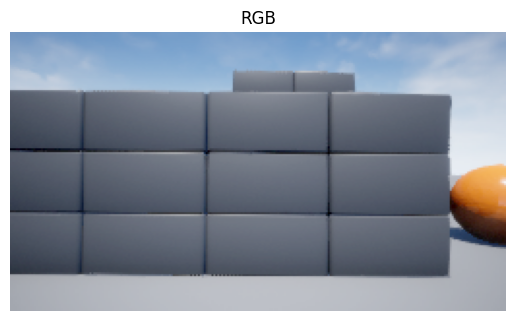

FRAME 9
position: [1.3440766334533691, 1.3426017761230469, -6.785987377166748] meters
velocity: [-1.2856781482696533, -1.2862589359283447, 0.7606514692306519] meters/sec


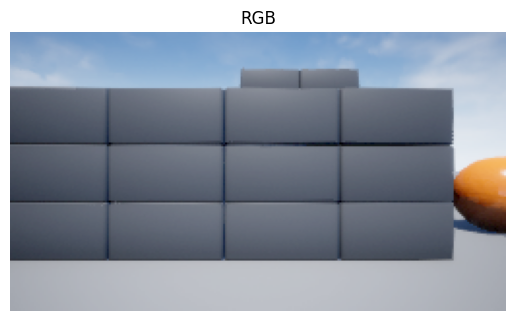

FRAME 10
position: [0.05863271281123161, 0.05817285180091858, -6.108404159545898] meters
velocity: [-1.2872871160507202, -1.2854366302490234, 0.7989159822463989] meters/sec


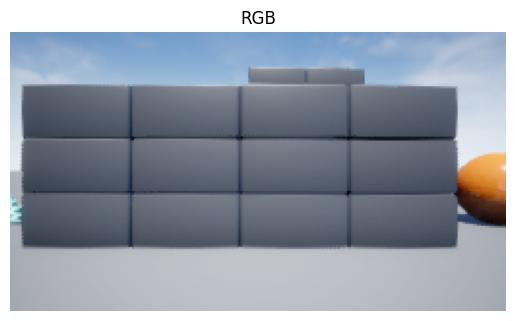

USER SET PARAMETERS: {'data_dir': 'data/run1/', 'airsim_map': 'BLOCKS', 'release_path': './maps/Blocks/LinuxBlocks1.8.1/LinuxNoEditor/Blocks.sh', 'default_settings': 'DEFAULT', 'base_settings_path': './settings/default.json', 'temp_settings_path': '/home/airsim/Desktop/airsim/settings/temp.json', 'display_windowed': True, 'display_animals': False, 'self_stabilize': True, 'mode_control': 'DURATION', 'drone_speed': 2, 'start_position': [0, 0, -4], 'positions_list': [[4, 4, -4], [4, 4, -8], [-4, -4, -4]], 'data_types': ['POSITION', 'VELOCITY', 'BGR'], 'frame_rate': 1, 'clock_speed': 1, 'collection_time': 10}


In [4]:
data_dir = './data/run1/'
frames_path = os.path.join(data_dir, 'frames.p')
params_path = os.path.join(data_dir, 'params.json')

frames = pickle.load(open(frames_path, 'rb'))
params = json.load(open(params_path, 'r'))

# helper functions
def bgr_rgb(bgr):
    b = bgr[:, :, 0].copy()
    g = bgr[:, :, 1].copy()
    r = bgr[:, :, 2].copy()
    rgb = np.stack([r, g, b], axis=2)
    return rgb

for frame_idx, frame in enumerate(frames):
    print('FRAME', frame_idx + 1)
    if 'POSITION' in frame:
        x, y, z = frame['POSITION']
        print(f'position: [{x}, {y}, {z}] meters')
    if 'VELOCITY' in frame:
        vx, vy, vz = frame['VELOCITY']
        print(f'velocity: [{vx}, {vy}, {vz}] meters/sec')
    if 'BGR' in frame:
        bgr = frame['BGR']
        rgb = bgr_rgb(bgr)
        plt.imshow(rgb)
        plt.title('RGB')
        plt.axis('off')
        plt.show()

print('USER SET PARAMETERS:', params)